# Imports

In [1]:
import os, sys
sys.path.append("..")

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from src.light_sb_ou import LightSB_OU
from tqdm import tqdm
import os
import gc
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from matplotlib.collections import LineCollection
import optuna
from scipy.stats import ortho_group  
from IPython.display import clear_output
from scipy.linalg import sqrtm
from scipy.optimize import curve_fit

%matplotlib inline

# Config

In [2]:
DIM = 2  
EPSILON = 9
D_LR = 2e-3
MAX_STEPS = 2000
BATCH_SIZE = 128
D_GRADIENT_MAX_NORM = float("inf")
N_POTENTIALS = 1
SAMPLING_BATCH_SIZE = 128
INIT_BY_SAMPLES = True
IS_DIAGONAL = False
OUTPUT_PATH = './gaussian_grid_results'
os.makedirs(OUTPUT_PATH, exist_ok=True)

In [3]:
def setup_consistent_evaluation(EVAL_SEED=0xBADBEEF):
    torch.manual_seed(EVAL_SEED)
    np.random.seed(EVAL_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(EVAL_SEED)

# Distribution

In [4]:
def create_target_distributions():
    setup_consistent_evaluation()
    means = [np.array([2.0, 1.0])]

    covs = [np.array([[0.3, 0.1], [0.1, 0.1]])]
    return means, covs

target_means, target_covs = create_target_distributions()

In [5]:
class StandardNormalSampler:
    def __init__(self, dim):
        self.dim = dim

    def sample(self, n):
        return torch.randn(n, self.dim)

class GaussianGridSampler:
    def __init__(self, means, covs):
        self.means = [torch.tensor(m, dtype=torch.float32) for m in means]
        self.covs = [torch.tensor(c, dtype=torch.float32) for c in covs]
        self.n_components = len(means)
        self.dim = len(means[0])

    def sample(self, n):
        component = torch.randint(0, self.n_components, (n,))
        samples = torch.zeros(n, self.dim)
        for i in range(n):
            c = component[i]
            samples[i] = torch.distributions.MultivariateNormal(
                self.means[c],
                covariance_matrix=self.covs[c]
            ).sample()
        return samples

X_sampler = StandardNormalSampler(DIM)
Y_sampler = GaussianGridSampler(target_means, target_covs)

In [6]:
def plot_distributions(source_samples, target_samples, transformed_samples=None, color_v="tab:orange", title="A",
                        filename=None, traj=False):
    plt.figure(figsize=(10, 10))

    plt.scatter(target_samples[:, 0], target_samples[:, 1], color='g',
                alpha=0.3, label='Target (Gaussian Mixture)')

    if transformed_samples is not None:
        plt.scatter(transformed_samples[:, 0], transformed_samples[:, 1], color=color_v,
                    alpha=0.3, label='Transformed')

    for mean in target_means:
        plt.plot(mean[0], mean[1], 'ro', markersize=8)

    plt.legend()
    plt.grid(True)
    plt.title(title)

    if filename:
        plt.savefig(os.path.join(OUTPUT_PATH, filename))
        plt.close()
    else:
        plt.show()

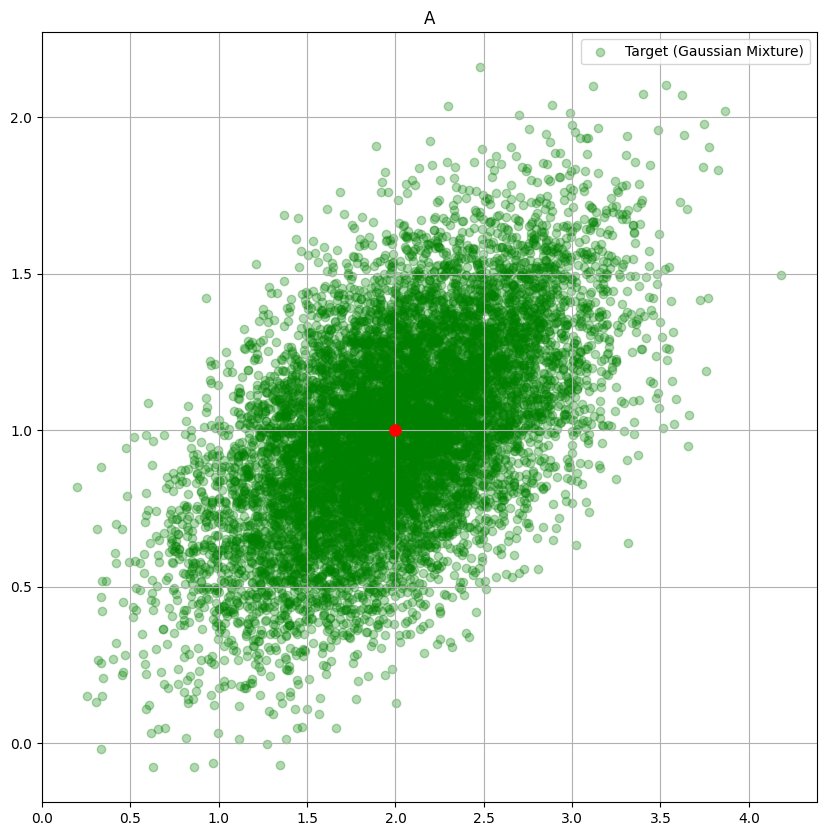

In [7]:
setup_consistent_evaluation()

plot_distributions(
    X_sampler.sample(10000).numpy(),
    Y_sampler.sample(10000).numpy(),
)

# Training

In [8]:
def train_final_model(b, mu, N_points=100, filename=None):
    final_D = LightSB_OU(
        dim=DIM,
        n_potentials=N_POTENTIALS,
        epsilon=EPSILON,
        b=b,
        m=mu,
        sampling_batch_size=SAMPLING_BATCH_SIZE,
        S_diagonal_init=0.1,
        is_diagonal=IS_DIAGONAL
    )

    X_sampler = StandardNormalSampler(DIM)
    Y_sampler = GaussianGridSampler(target_means, target_covs)

    Y_fixed = Y_sampler.sample(COUNT_POINTS)

    if INIT_BY_SAMPLES:
        final_D.init_r_by_samples(Y_sampler.sample(N_POTENTIALS))

    final_D_opt = torch.optim.Adam(final_D.parameters(), lr=D_LR)

    loss_history = []
    grad_norm_history = []

    for step in range(MAX_STEPS):
        final_D_opt.zero_grad()

        X0 = X_sampler.sample(BATCH_SIZE)
        indices = torch.randint(0, COUNT_POINTS, (BATCH_SIZE,))
        X1 = Y_fixed[indices]

        log_potential = final_D.get_log_potential(X1)
        log_C = final_D.get_log_C(X0)

        D_loss = (-log_potential + log_C).mean()
        D_loss.backward()
        D_gradient_norm = torch.nn.utils.clip_grad_norm_(final_D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
        final_D_opt.step()

        loss_history.append(D_loss.item())
        grad_norm_history.append(D_gradient_norm.item())

    return final_D, loss_history, grad_norm_history

# Optimal Coupling

In [9]:
def compute_optimal_parameters(mu_0, Q_0, mu_T, Q_T, b, epsilon, T, m=0):
    mu_0_np = mu_0.numpy() if torch.is_tensor(mu_0) else mu_0
    Q_0_np = Q_0.numpy() if torch.is_tensor(Q_0) else Q_0
    mu_T_np = mu_T.numpy() if torch.is_tensor(mu_T) else mu_T
    Q_T_np = Q_T.numpy() if torch.is_tensor(Q_T) else Q_T

    Q_0_sqrt = sqrtm(Q_0_np)
    Q_0_sqrt_inv = np.linalg.inv(Q_0_sqrt)

    sigma_T_sq = (1 - np.exp(-2*b*T)) / (2*b) if b > 1e-1 else 1 - b + (2/3) * b**2

    inner_matrix = 4 * Q_0_sqrt @ Q_T_np @ Q_0_sqrt + (np.exp(2*b*T) * sigma_T_sq**2 * epsilon**2) * np.eye(len(Q_0_np))
    A = 0.5 * (Q_0_sqrt @ sqrtm(inner_matrix) @ Q_0_sqrt_inv -
               np.exp(b*T) * sigma_T_sq * epsilon * np.eye(len(Q_0_np)))

    tilde_Q_T = Q_T_np - A.T @ np.linalg.inv(Q_0_np) @ A

    S_star = tilde_Q_T / (epsilon * sigma_T_sq)
    r_star = mu_T_np - S_star @ (mu_0_np * np.exp(-b*T) + m * (1 - np.exp(-b*T)))

    return torch.tensor(r_star, dtype=torch.float32), torch.tensor(S_star, dtype=torch.float32)

def compute_kl_divergence(model, r_star, S_star, mu_0, Q_0, mu_T, Q_T, b, epsilon, T, m):
    r = model.get_r()[0]  
    S = model.get_S()[0]  

    r_np = r.detach().numpy()
    S_np = S.detach().numpy()
    r_star_np = r_star.numpy() if torch.is_tensor(r_star) else r_star
    S_star_np = S_star.numpy() if torch.is_tensor(S_star) else S_star
    mu_0_np = mu_0.numpy() if torch.is_tensor(mu_0) else mu_0
    Q_0_np = Q_0.numpy() if torch.is_tensor(Q_0) else Q_0
    mu_T_np = mu_T.numpy() if torch.is_tensor(mu_T) else mu_T
    Q_T_np = Q_T.numpy() if torch.is_tensor(Q_T) else Q_T

    sigma_T_sq = (1 - np.exp(-2*b*T)) / (2*b) if b > 1e-1 else 1 - b + (2/3) * b**2
    decay_factor = np.exp(-b*T)

    S_inv = np.linalg.inv(S_np)
    S_star_inv = np.linalg.inv(S_star_np)

    term1_part1 = (mu_T_np - r_np).T @ S_inv @ (mu_T_np - r_np)
    term1_part2 = (mu_T_np - r_star_np).T @ S_star_inv @ (mu_T_np - r_star_np)
    term1_part3 = np.trace(Q_T_np @ (S_inv - S_star_inv))

    term1 = (term1_part1 - term1_part2 + term1_part3) / (2 * epsilon)

    term2 = 0.5 * (np.log(np.linalg.det(S_np @ S_star_inv)))

    m_T_mu_0 = mu_0_np * np.exp(-b*T) + m * (1 - np.exp(-b*T))

    term3_part1 = (r_np - r_star_np).T @ m_T_mu_0 / (epsilon * sigma_T_sq)

    term3_part2 = (m_T_mu_0.T @ S_np @ m_T_mu_0 - m_T_mu_0.T @ S_star_np @ m_T_mu_0) / (2 * epsilon * sigma_T_sq)

    term3_part3 = np.trace(Q_0_np @ (S_np - S_star_np)) * np.exp(-2*b*T) / (2 * epsilon * sigma_T_sq)

    term3 = term3_part1 + term3_part2 + term3_part3

    kl_div = term1 + term2 + term3

    return kl_div

In [10]:
true_r, true_S = compute_optimal_parameters(np.array([0.0, 0.0]), np.array([[1.0, 0.0], [0.0, 1.0]]), np.array([2.0, 1.0]), np.array([[0.3, 0.1], [0.1, 0.1]]),\
                                            0, EPSILON, 0)
true_r, true_S

(tensor([2., 1.]),
 tensor([[0.0332, 0.0111],
         [0.0111, 0.0111]]))

In [11]:
res_kl = []
# counters = [250, 500, 10**3, 2* 10**3, 4 * 10**3, 8 * 10**3, 16 * 10**3, 32 * 10**3]
counters = [250, 500, 10**3, 2* 10**3, 4 * 10**3, 8 * 10**3, 16 * 10**3]
for counter in counters:
    COUNT_POINTS = counter
    kl_ar = []
    for seed in [10, 346, 2]:
        setup_consistent_evaluation(seed)
        model, loss_history, grad_history = train_final_model(2, 0.0, counter, True)
    
        kl = compute_kl_divergence(model, true_r, true_S, np.array([0.0, 0.0]), np.array([[1.0, 0.0], [0.0, 1.0]]), np.array([2.0, 1.0]), \
                                    np.array([[0.3, 0.1], [0.1, 0.1]]), 2, EPSILON, 1.0, 0.0)
        kl_ar.append(kl)
    
    res_kl.append(np.mean(kl_ar))

y = 0.011309 × (log^3(n)/n)
R² = 0.941225
Residual Sum of Squares = 2.545850e-06


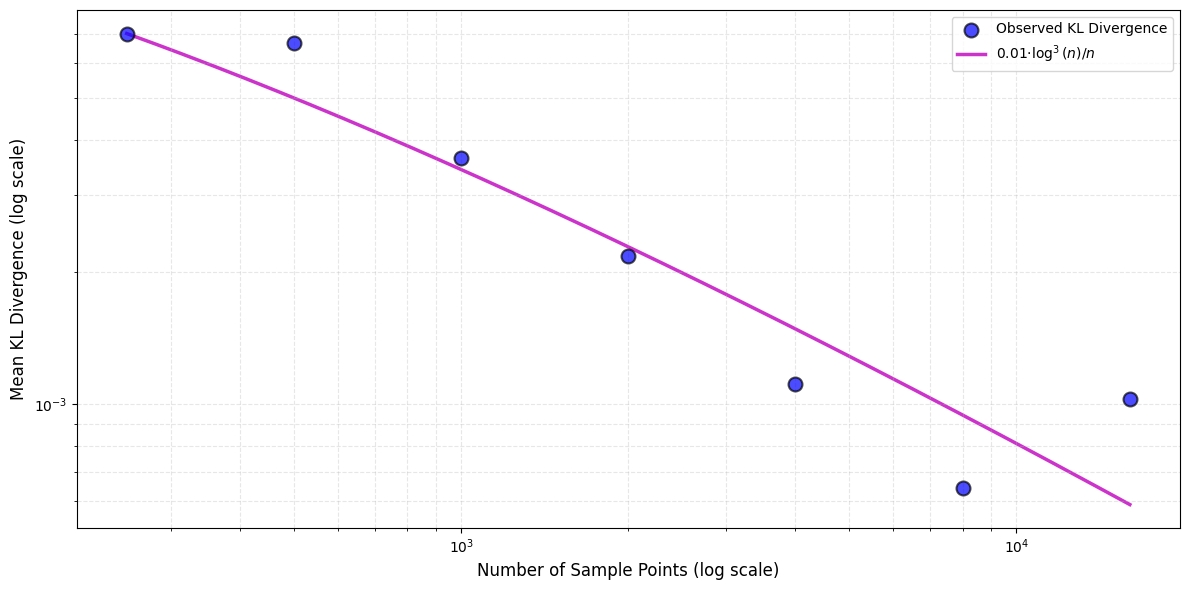

In [12]:
x_data = np.array(counters)
y_data = np.array(res_kl)

x_smooth = np.linspace(min(x_data), max(x_data), 1000)

log_cubed_over_n = (np.log(x_smooth) ** 3) / x_smooth

scale_factor = y_data[0] / ((np.log(x_data[0]) ** 3) / x_data[0])
log_cubed_over_n_scaled = log_cubed_over_n * scale_factor

log_cubed_over_n_data = (np.log(x_data) ** 3) / x_data
scale_factor_data = np.sum(y_data * log_cubed_over_n_data) / np.sum(log_cubed_over_n_data ** 2)
log_cubed_over_n_fitted = log_cubed_over_n_data * scale_factor_data
residuals_log3 = y_data - log_cubed_over_n_fitted
ss_res_log3 = np.sum(residuals_log3**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared_log3 = 1 - (ss_res_log3 / ss_tot)

plt.figure(figsize=(12, 6))

plt.scatter(x_data, y_data, s=100, color='blue', alpha=0.7,
            label='Observed KL Divergence', zorder=4, edgecolors='black', linewidths=1.5)

plt.plot(x_smooth, log_cubed_over_n_scaled, 'm-', linewidth=2.5, alpha=0.8,
         label=str(scale_factor.round(2)) + r'$\cdot \log^3(n)/n$', zorder=1)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Sample Points (log scale)', fontsize=12)
plt.ylabel('Mean KL Divergence (log scale)', fontsize=12)
plt.grid(True, alpha=0.3, which='both', linestyle='--')
plt.legend(fontsize=10, loc='best')
plt.tight_layout()

print(f"y = {scale_factor_data:.6f} × (log^3(n)/n)")
print(f"R² = {r_squared_log3:.6f}")
print(f"Residual Sum of Squares = {ss_res_log3:.6e}")

plt.show()